In [43]:
import networkx as nx
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
network1 = nx.read_gml('Networks/t3_p007p_f007p_c.gml')
network2 = nx.read_gml('Networks/t3_r007p_f007p_c.gml')
network3 = nx.read_gml('Networks/t3_r007p_p007p_c.gml')
network4 = nx.read_gml('Networks/t3_r007p_p007p_f007p_c.gml')

In [21]:
books = pd.read_csv('Data/BookData.csv', index_col=0)[['tags']]

In [24]:
tags_df = books['tags'].str.get_dummies(sep=';')
tags_df.head(5)

,Action,Adventure,Anti-Hero Lead,Artificial Intelligence,Attractive Lead,Comedy,Contemporary,Cyberpunk,Drama,Dungeon,...,Technologically Engineered,Time Loop,Time Travel,Tragedy,Urban Fantasy,Villainous Lead,Virtual Reality,War and Military,Wuxia,Xianxia
id,,,,,,,,,,,,,,,,,,,,,
21220,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
36735,0,1,1,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
21410,1,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
63759,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
65629,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [13]:
# print number of nodes 
print("Number of nodes in network1:", network1.number_of_nodes())
print("Number of nodes in network2:", network2.number_of_nodes())
print("Number of nodes in network3:", network3.number_of_nodes())
print("Number of nodes in network4:", network4.number_of_nodes())

Number of nodes in network1: 1999
Number of nodes in network2: 1999
Number of nodes in network3: 1999
Number of nodes in network4: 1999


In [8]:
def get_community_bridges(G, method="participation", top_n=None):
    if method == "participation":
        def participation_coefficient(G, node):
            neighbor_communities = [G.nodes[neighbor]['community'] for neighbor in G.neighbors(node)]
            k_i = len(neighbor_communities)
            if k_i == 0:
                return 0
            counts = Counter(neighbor_communities)
            return 1 - sum((count / k_i) ** 2 for count in counts.values())
        values = {node: participation_coefficient(G, node) for node in G.nodes}
    elif method == "betweenness":
        values = nx.betweenness_centrality(G)
    else:
        raise ValueError("method must be either 'participation' or 'betweenness'")

    # Sort nodes by value descending and convert to list of tuples
    sorted_nodes = sorted(values.items(), key=lambda x: x[1], reverse=True)
    if top_n is not None:
        sorted_nodes = sorted_nodes[:top_n]
    return sorted_nodes

In [44]:
def plot_top_bridge_tags(network, tags_df, top_n=100, top_tags=20):
    # Get top bridge nodes for each method
    bridges_betweenness = get_community_bridges(network, method="betweenness", top_n=top_n)
    bridges_participation = get_community_bridges(network, method="participation", top_n=top_n)

    # Extract node indexes (convert to int for index matching)
    betweenness_indexes = [int(elem[0]) for elem in bridges_betweenness]
    participation_indexes = [int(elem[0]) for elem in bridges_participation] 

    # Filter tags_df to only include bridge nodes, then transpose
    tags_betweenness_df = tags_df.loc[tags_df.index.isin(betweenness_indexes)].T
    tags_participation_df = tags_df.loc[tags_df.index.isin(participation_indexes)].T

    # Calculate tag counts and take only the top N tags for clarity
    betweenness_counts = tags_betweenness_df.sum(axis=1).sort_values(ascending=False).head(top_tags)
    participation_counts = tags_participation_df.sum(axis=1).sort_values(ascending=False).head(top_tags)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
    
    sns.barplot(x=betweenness_counts.values, y=betweenness_counts.index, ax=axes[0], palette="viridis")
    axes[0].set_title(f"Top {top_tags} Tags (Betweenness Bridge Nodes)")
    axes[0].set_xlabel("Book Count")
    axes[0].set_ylabel("Tag")
    
    sns.barplot(x=participation_counts.values, y=participation_counts.index, ax=axes[1], palette="magma")
    axes[1].set_title(f"Top {top_tags} Tags (Participation Bridge Nodes)")
    axes[1].set_xlabel("Book Count")
    axes[1].set_ylabel("Tag")
    
    plt.tight_layout()
    plt.show()


/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=betweenness_counts.values, y=betweenness_counts.index, ax=axes[0], palette="viridis")
/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=participation_counts.values, y=participation_counts.index, ax=axes[1], palette="magma")


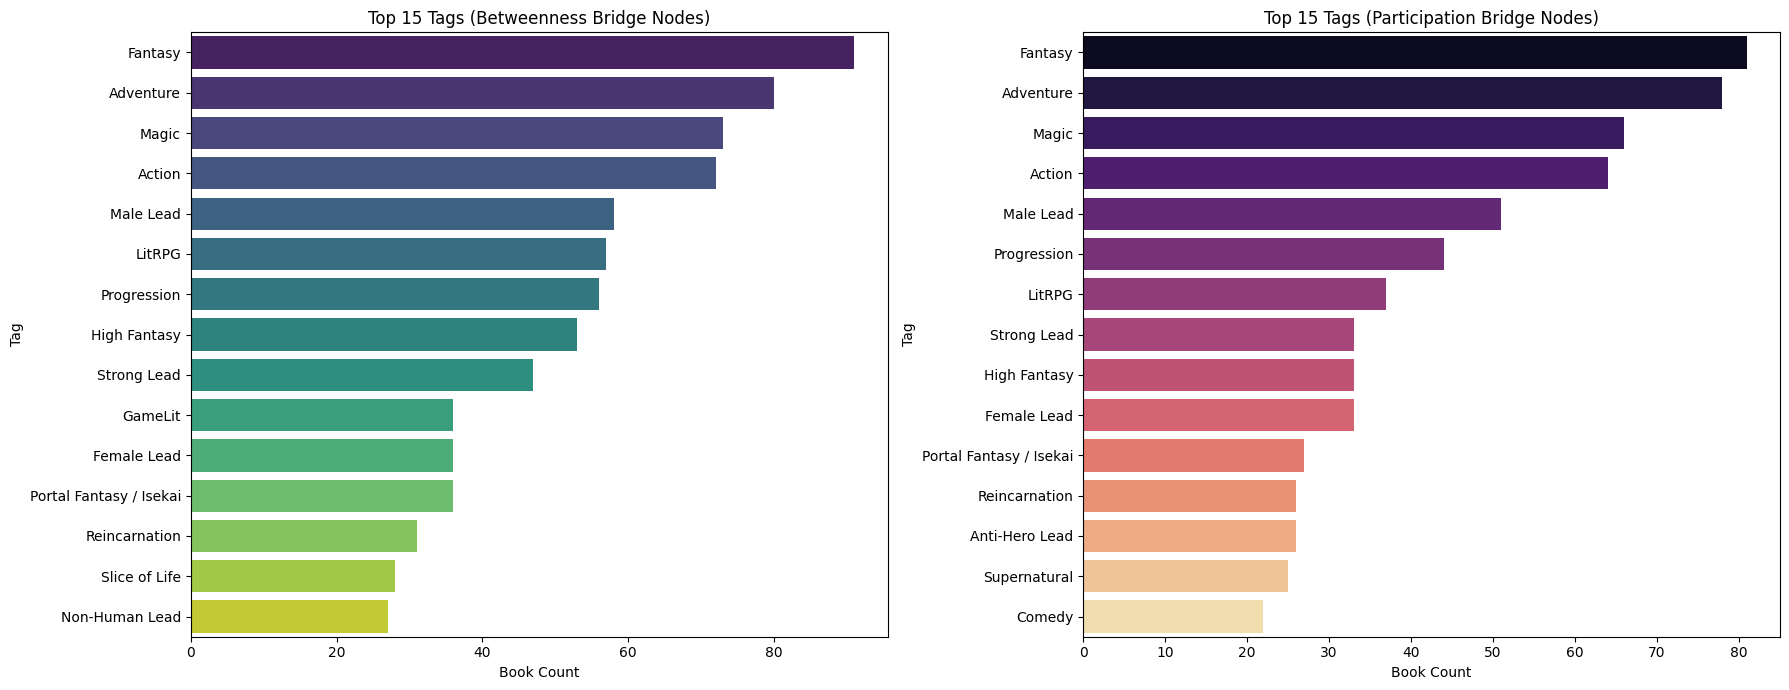

In [47]:
plot_top_bridge_tags(network1, tags_df, top_n=100, top_tags=15)

/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=betweenness_counts.values, y=betweenness_counts.index, ax=axes[0], palette="viridis")
/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=participation_counts.values, y=participation_counts.index, ax=axes[1], palette="magma")


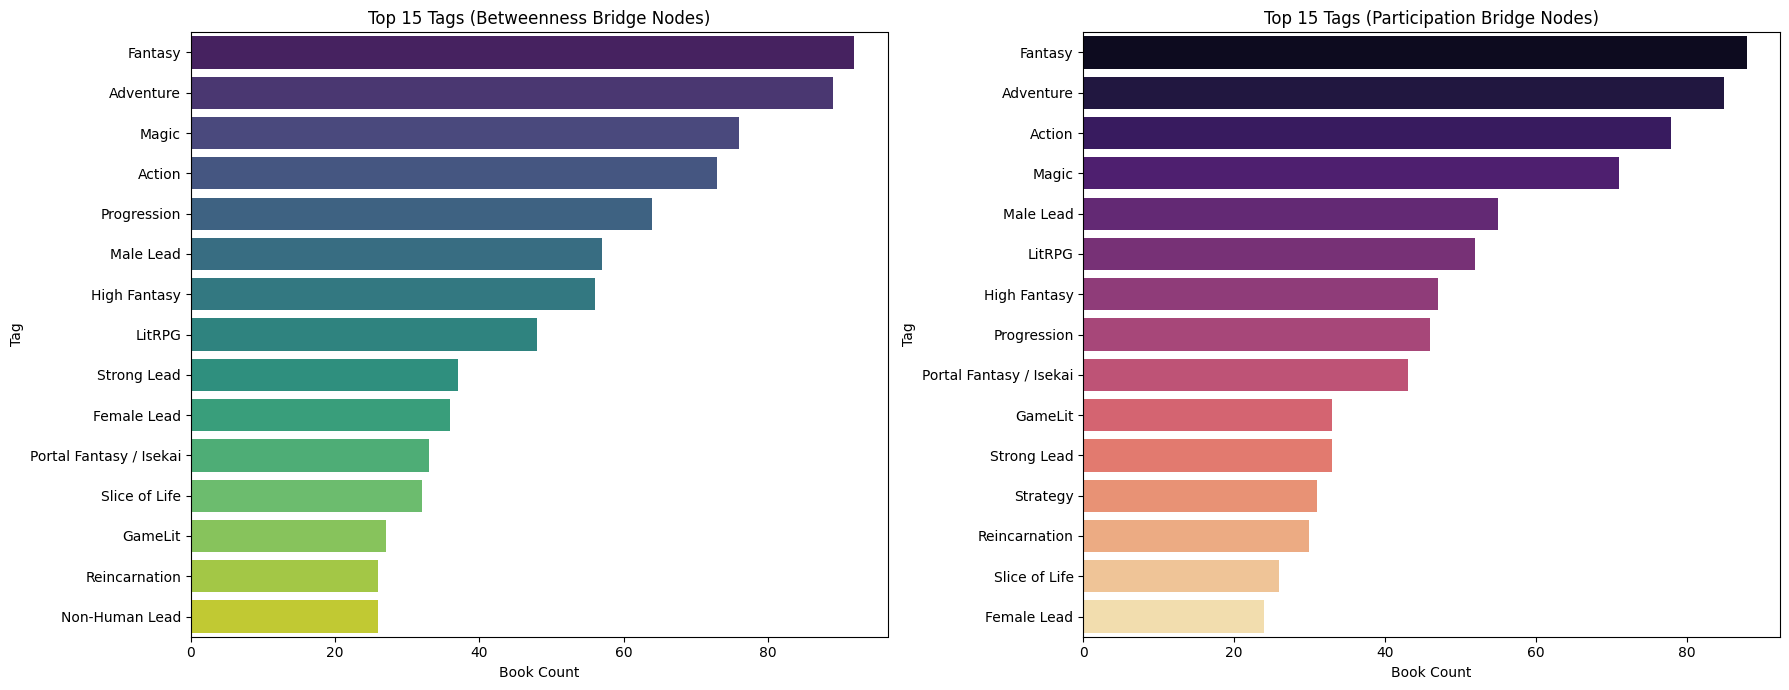

In [49]:
plot_top_bridge_tags(network2, tags_df, top_n=100, top_tags=15)

/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=betweenness_counts.values, y=betweenness_counts.index, ax=axes[0], palette="viridis")
/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=participation_counts.values, y=participation_counts.index, ax=axes[1], palette="magma")


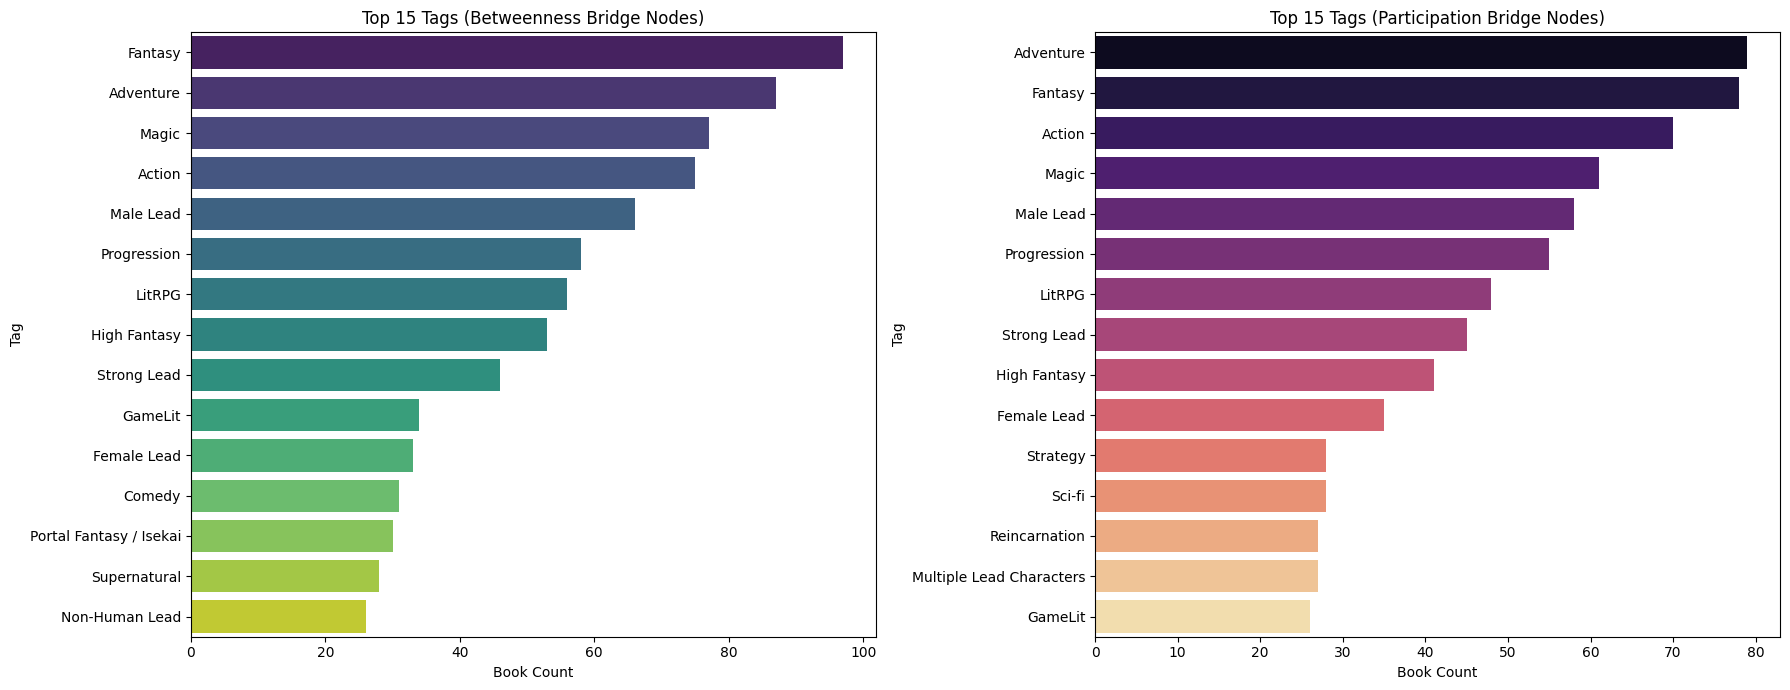

In [50]:
plot_top_bridge_tags(network3, tags_df, top_n=100, top_tags=15)

/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=betweenness_counts.values, y=betweenness_counts.index, ax=axes[0], palette="viridis")
/var/folders/wp/ldd99l4s29j22w9n5ss62hnc0000gn/T/ipykernel_46828/3400768529.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=participation_counts.values, y=participation_counts.index, ax=axes[1], palette="magma")


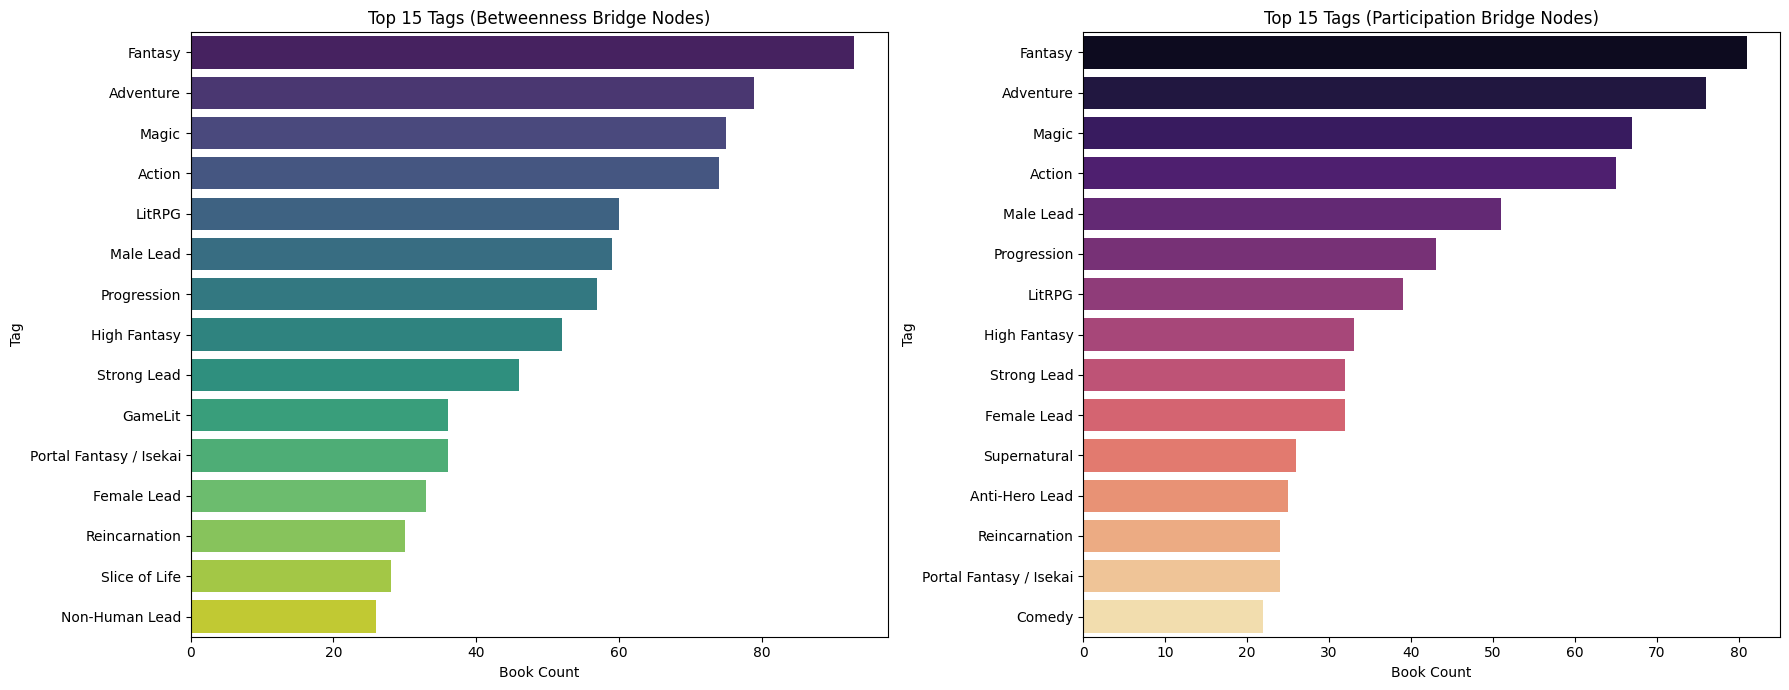

In [51]:
plot_top_bridge_tags(network4, tags_df, top_n=100, top_tags=15)